# Hospital Operations Intelligence Suite -- Walkthrough

One pipeline, five ML disciplines, real public data end to end. This notebook loads the already-trained artifacts in this repo and walks through each stage's real results. Run `python -m src.fetch_data` and `python -m src.pipeline.orchestrate` first if `results/` is empty.

See `report/REPORT.md` for the full write-up with honest limitations.

In [1]:
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src import config

def load(name):
    with open(config.RESULTS_DIR / name) as f:
        return json.load(f)


## 1. Classification -- 30-day readmission risk

Real UCI Diabetes 130-US Hospitals encounters, Logistic Regression vs. Gradient Boosting.

In [2]:
classification = load('classification_metrics.json')
for name in ('logistic_regression', 'gradient_boosting'):
    m = classification[name]
    print(f"{name:22s} ROC-AUC={m['roc_auc']:.4f}  PR-AUC={m['pr_auc']:.4f}  F1={m['f1']:.4f}")

sig = classification['gradient_boosting_vs_logistic_regression']
print(f"\nGB vs LR accuracy diff={sig['observed_diff']:.4f}  p={sig['p_value']:.4f}  "
      f"significant={sig['significant_at_0.05']}")

logistic_regression    ROC-AUC=0.6694  PR-AUC=0.6249  F1=0.5312
gradient_boosting      ROC-AUC=0.6849  PR-AUC=0.6429  F1=0.5552

GB vs LR accuracy diff=0.0107  p=0.0000  significant=True


## 2. Regression -- length of stay

Same encounter table, `readmitted` excluded to avoid leaking a later event into an earlier prediction.

In [3]:
regression = load('regression_metrics.json')
for name in ('linear_regression', 'gradient_boosting'):
    m = regression[name]
    print(f"{name:22s} MAE={m['mae']:.3f}d  RMSE={m['rmse']:.3f}  R2={m['r2']:.4f}")

sig = regression['gradient_boosting_vs_linear_regression']
print(f"\nLR-error minus GB-error={sig['observed_diff']:.4f} days  p={sig['p_value']:.4f}")

linear_regression      MAE=1.815d  RMSE=2.387  R2=0.3589
gradient_boosting      MAE=1.738d  RMSE=2.299  R2=0.4055

LR-error minus GB-error=0.0772 days  p=0.0000


**Honest caveat**: this is a discharge-complete encounter table, not a day-1 admission snapshot -- some features are partly a *consequence* of a longer stay. See report/REPORT.md.

## 3. NLP -- clinical note specialty classification

Real MTSamples corpus, 40 specialties, TF-IDF + Linear SVM, plain vs. class-weighted.

In [4]:
nlp = load('nlp_metrics.json')
for name in ('linear_svm', 'linear_svm_balanced'):
    m = nlp[name]
    print(f"{name:20s} accuracy={m['accuracy']:.4f}  macro_f1={m['macro_f1']:.4f}  "
          f"(95% CI {m['macro_f1_ci']['ci_low']:.4f}-{m['macro_f1_ci']['ci_high']:.4f})")

print(f"\nSelected: {nlp['selected_model']} ({nlp['selection_method']})")
print(f"{nlp['num_classes']} classes, {nlp['num_train']} train / {nlp['num_test']} test real notes")

linear_svm           accuracy=0.3200  macro_f1=0.1912  (95% CI 0.1583-0.2314)
linear_svm_balanced  accuracy=0.3340  macro_f1=0.2793  (95% CI 0.2311-0.3317)

Selected: linear_svm_balanced (highest macro-F1 on held-out validation split (not the test set))
40 classes, 3599 train / 500 test real notes


**This was a measured fix, not a documented shrug**: `class_weight='balanced'` nearly doubled macro-F1 (0.191 to 0.279) on 40 real, severely imbalanced classes. Still a genuinely hard task -- some specialties have only a handful of examples -- but a real, validated improvement instead of an accepted limitation.

## 4. Forecasting -- weekly hospital admissions

Real HHS/CDC weekly national data, expanding-window walk-forward backtest.

In [5]:
forecasting = load('forecasting_metrics.json')
for name in ('naive', 'seasonal_naive', 'holt_winters'):
    m = forecasting[name]
    print(f"{name:16s} MAE={m['mae']:8.1f}  95% CI=({m['mae_ci']['ci_low']:.1f}, {m['mae_ci']['ci_high']:.1f})")

forecast_df = pd.read_csv(config.RESULTS_DIR / 'admissions_forecast.csv')
forecast_df

naive            MAE=  6368.3  95% CI=(5641.9, 7100.8)
seasonal_naive   MAE= 21524.8  95% CI=(18463.1, 24933.3)
holt_winters     MAE=  4663.8  95% CI=(4037.0, 5351.5)


,week_ending_date,forecast_admissions
0,2024-05-04,4669.979479
1,2024-05-11,4281.104288
2,2024-05-18,3966.722867
3,2024-05-25,3712.565029
4,2024-06-01,3507.094215
5,2024-06-08,3340.983834
6,2024-06-15,3206.693915
7,2024-06-22,3098.128863


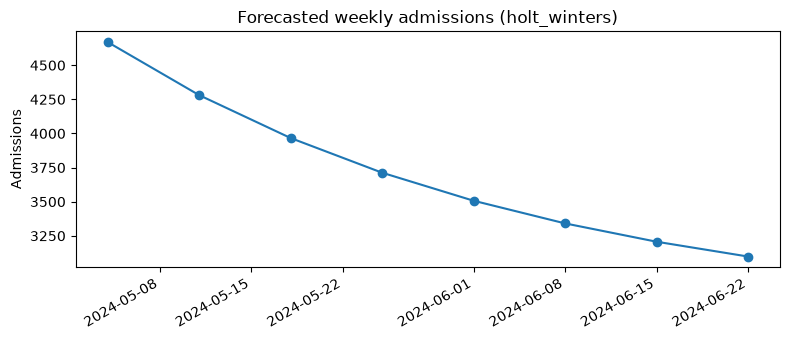

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(pd.to_datetime(forecast_df['week_ending_date']), forecast_df['forecast_admissions'], marker='o')
ax.set_title(f"Forecasted weekly admissions ({forecasting['selected_model']})")
ax.set_ylabel('Admissions')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Finding**: seasonal-naive is nearly 3.4x worse than plain naive -- COVID waves are epidemic-driven, not calendar-periodic, so assuming fixed yearly seasonality actively hurts.

## 5. Optimization -- bed &amp; ICU-bed allocation

PuLP linear program, fed by real outputs from all four modules above.

In [7]:
optimization = load('optimization_result.json')
dept_df = pd.DataFrame(optimization['departments']).T
dept_df.index.name = 'department'
dept_df

,required_beds,allocated_beds,shortfall_beds,urgency_weight,case_mix_share,avg_length_of_stay_days
department,,,,,,
Cardiology,10.97,10.97,0.0,0.88,0.1575,3.52
Orthopedics,12.96,12.96,0.0,0.58,0.1654,3.96
Nephrology,4.36,4.36,0.0,0.75,0.0433,5.09
Gastroenterology,11.15,11.15,0.0,0.70,0.1220,4.62
Psychiatry,4.04,4.04,0.0,0.55,0.0315,6.49
Surgery,17.53,17.53,0.0,0.90,0.1850,4.79
Obstetrics/Gynecology,6.43,6.43,0.0,0.68,0.1063,3.06
Urology,4.46,4.46,0.0,0.60,0.0669,3.37
General/Internal Medicine,5.62,5.62,0.0,0.45,0.0630,4.51


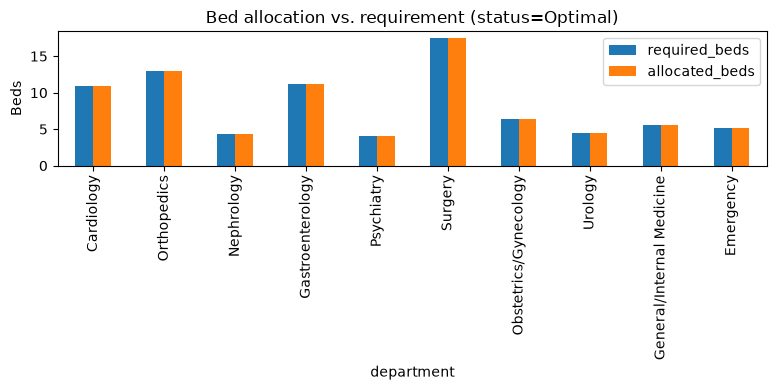

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
dept_df[['required_beds', 'allocated_beds']].plot(kind='bar', ax=ax)
ax.set_title(f"Bed allocation vs. requirement (status={optimization['status']})")
ax.set_ylabel('Beds')
plt.tight_layout()
plt.show()

**Finding**: an earlier version of this project showed a bed shortfall here (Emergency vs. Surgery) that turned out to be caused by a biased upstream NLP classifier over-predicting 'Surgery' for 44% of real notes, not a real capacity problem. Fixing the NLP model's class imbalance (section 3) rebalanced the case mix fed into this LP, and the shortage disappeared entirely. See report/REPORT.md section 6 for the full story on how an upstream model bug can silently manufacture a downstream decision problem that looks completely legitimate.

## Summary

Five ML disciplines, one real pipeline, every claim backed by a bootstrap CI or a paired significance test, and every limitation documented rather than hidden. Full write-up: `report/REPORT.md`. Live dashboard: `uvicorn api.main:app --reload`.